In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Cleaning data

In [2]:
cols = ['MJD','R.A. (mas)', 'Dec. (mas)', 'Err.  R.A. (mas)', 'Err. Dec. (mas)', 'Corr.', 'Del.']

In [3]:
df = pd.read_csv('1611+343_dem.txt', sep='\s+', skiprows=4, names=cols, header=None, index_col=False)
df

,MJD,R.A. (mas),Dec. (mas),Err. R.A. (mas),Err. Dec. (mas),Corr.,Del.
0,47165.332,1.472508508776,4.937699,0.5046,1.0159,-0.003,21.0
1,47610.794,47.422934132828,7.737098,3.1809,1.6415,0.835,3.0
2,47620.338,0.554842071180,-0.460800,1.0507,1.1907,-0.022,11.0
3,47640.018,243.542065677985,-967.786099,6.7731,6.0100,-0.593,3.0
4,47655.329,2.151144023812,2.641702,0.7536,0.9041,0.061,20.0
...,...,...,...,...,...,...,...
2045,59346.229,-0.512791685462,-1.148699,0.2870,0.3626,0.093,49.0
2046,59348.271,-1.160293539259,-0.345802,0.1943,0.2444,0.385,78.0
2047,59374.251,-1.077559166964,2.305400,0.3242,0.7562,-0.161,13.0
2048,59430.248,0.144135352532,-0.896602,0.3406,0.7687,-0.240,12.0


In [4]:
df.dtypes

MJD                 float64
R.A. (mas)           object
Dec. (mas)          float64
Err.  R.A. (mas)    float64
Err. Dec. (mas)     float64
Corr.               float64
Del.                float64
dtype: object

In [6]:
# Convert RA to float64
df['R.A. (mas)'] = pd.to_numeric(df['R.A. (mas)'])

ValueError: Unable to parse string "94.187949744281-1043.354199606483" at position 1355

In [8]:
# Examine problematic row
df.loc[[1355]]

,MJD,R.A. (mas),Dec. (mas),Err. R.A. (mas),Err. Dec. (mas),Corr.,Del.
1355,53782.836,94.187949744281-1043.354199606483,0.5091,0.747,-0.24,45.0,NaN


In [9]:
# Shift data values
df.iloc[1355, :] = df.iloc[1355, :].shift()
df.iloc[1355,0] = df.iloc[1355,1]
df.loc[[1355]]

,MJD,R.A. (mas),Dec. (mas),Err. R.A. (mas),Err. Dec. (mas),Corr.,Del.
1355,53782.836,53782.8,94.187949744281-1043.354199606483,0.5091,0.747,-0.24,45.0


In [10]:
df.iloc[1355,1], df.iloc[1355,2] = df.iloc[1355,2].split('-')
df.loc[[1355]]

,MJD,R.A. (mas),Dec. (mas),Err. R.A. (mas),Err. Dec. (mas),Corr.,Del.
1355,53782.836,94.187949744281,1043.354199606483,0.5091,0.747,-0.24,45.0


In [11]:
# Convert RA to float64
df['R.A. (mas)'] = pd.to_numeric(df['R.A. (mas)'])

In [14]:
# Convert RA to float64
df['Dec. (mas)'] = pd.to_numeric(df['Dec. (mas)'])

In [15]:
# Calculate RA*cos(dec) column
df['RAcosDEC'] = df['R.A. (mas)']*np.cos(df['Dec. (mas)'])

In [17]:
# Change MJD to BY 
# BY=2000-(51544.333981-MJD)/365.242198781
df['BY'] = 2000-(51544.333981-df['MJD'])/365.242198781

In [18]:
df.head(5)

,MJD,R.A. (mas),Dec. (mas),Err. R.A. (mas),Err. Dec. (mas),Corr.,Del.,RAcosDEC,BY
0,47165.332,1.472509,4.937699,0.5046,1.0159,-0.003,21.0,0.328971,1988.010690
1,47610.794,47.422934,7.737098,3.1809,1.6415,0.835,3.0,5.530333,1989.230324
2,47620.338,0.554842,-0.460800,1.0507,1.1907,-0.022,11.0,0.496970,1989.256455
3,47640.018,243.542066,-967.786099,6.7731,6.0100,-0.593,3.0,239.798472,1989.310337
4,47655.329,2.151144,2.641702,0.7536,0.9041,0.061,20.0,-1.887919,1989.352257


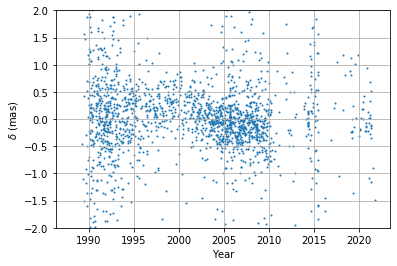

In [19]:
plt.scatter(df['BY'], df['Dec. (mas)'],s=1)
#plt.errorbar(df['BY'], df['Dec. (mas)'], yerr=df['Err. Dec. (mas)'], fmt='o', ecolor='grey')
plt.ylim(-2,2)
plt.xlabel('Year')
plt.ylabel('$\delta$ (mas)')
plt.grid()
plt.show()

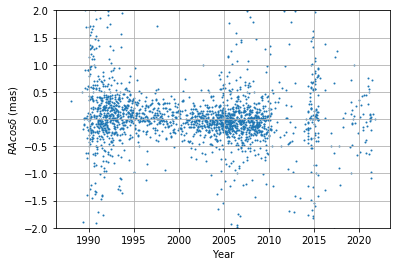

In [20]:
plt.scatter(df['BY'], df['RAcosDEC'],s=1)
plt.ylim(-2,2)
plt.xlabel('Year')
plt.ylabel('$RAcos \delta$ (mas)')
plt.grid()
plt.show()

# Allan Deviation

In [21]:
def allanoadev(y,rate):
        
    # === Parameters ===
    
    N = len(y)
    # m array where 3 < m < N/3 
    m = np.arange(3,1+round(N//3),1)
    # Take tau0 as 1/rate
    tau0 = 1/rate
    # steps
    step = 1
    
    # Empty variance array
    allanvar = []
    # Empty tau values array 
    tau = []

    # Iterate over values of m
    for k in range(len(m)): 
        # M is the number of times we can move the averaging window from the beginning to the end
        M = N-m[k]+1

        # Calculate allan var 
        outersum = []
        for j in np.arange(0,M-2*m[k]+1,step):
            innersum = []
            for i in np.arange(j,j+m[k]-1,step):
                innersum.append(y[i+m[k]]-y[i])
            outersum.append(0.5*(np.sum(innersum)/m[k])**2)

        # Calculate allan variance
        allanvar.append(np.sum(outersum)/(M-2*m[k]+1))
        
        # Calculate tau
        tau.append(tau0*m[k])

    # Calculate allan std dev
    allanstd = np.sqrt(allanvar)
        
    return tau, allanstd


In [22]:
%%time
tau_dec, allanstd_dec = allanoadev(df['Dec. (mas)'].values,1)

CPU times: user 1min 43s, sys: 790 ms, total: 1min 43s
Wall time: 1min 41s


In [23]:
tau_year_dec = [x/365 for x in tau_dec]

Text(0, 0.5, 'Allan std dev in $\\delta$ [mas?]')

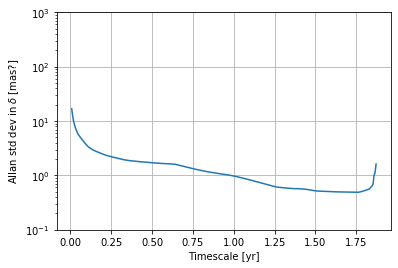

In [24]:
plt.plot(tau_year_dec,allanstd_dec)
plt.yscale('log')
plt.ylim(10**(-1),10**3)
plt.grid()
plt.xlabel('Timescale [yr]')
plt.ylabel('Allan std dev in $\delta$ [mas?]')

In [ ]:
%%time
tau_RAcosdec, allanstd_RAcosdec = allanoadev(df['RAcosDEC'].values,1)

In [ ]:
tau_year_RAcosdec = [x/365 for x in tau_RAcosdec]

In [ ]:
plt.plot(tau_year_RAcosdec,allanstd_RAcosdec)
plt.yscale('log')
plt.ylim(10**(-1),10**3)
plt.grid()
plt.xlabel('Timescale [yr]')
plt.ylabel('Allan std dev in acos$\delta$ [mas?]')